### THE TRANSIENT UNIVERSE

### Tasks

**Remember this is a real research example, not an exam! You're welcome (and encouraged actually!) to use all the tutorials/answers/hack you find online!**


1) Read in `solutions/transient.npy`. This is a (100 x 3) numpy array, containing some time-series measurements from a transient phenomenon. The first column is time (arbitrary units), the second column is the flux (arbitrary units), and the third column are homoescedastic measurement uncertainties on the flux. Plot this data with the uncertainties.

2) One possible model for this data is a sharp burst with an exponential tail rising above a nominal background level. This model can be described as:

$y = b$, for $t<t_0$

$y = b + A\exp[-\alpha(t-t_0)]$, for $t\geq t_0$

where $b$ is the background amplitude, $A$ is the burst amplitude, $t_0$ is the burst epoch, and $\alpha$ encodes how rapidly the burst dies off.

Code this burst model, and code a likelihood function for this data with the burst model. *Hint: This is similar in spirit to the likelihood when fitting polynomials to data, except now $x$ is time, and the polynomial model is now the burst model.* 

3) Using one of the MCMC sampler that we looked at in class (`emcee`, `pymc`), perform a Bayesian analysis that recovers an MCMC chain of posterior probability samples for the joint parameter space of $\{b,A,t_0,\alpha\}$. You must decide on how many samples are appropriate for running your MCMC. For your priors, make them $b\in \mathrm{Uniform}[0,50]$, $A\in \mathrm{Uniform}[0,50]$, $t_0\in \mathrm{Uniform}[0,100]$, and $\ln\alpha\in \mathrm{Uniform}[-5,5]$ (careful: uniform in $\ln\alpha$, not $\alpha$).

4) Perform an appropriate check to burn-in your chain, and thin the chain by selecting only points every auto-correlation length. If you are left with a small number of samples after thinning then you may need to run your MCMC for longer in (3).

5) Make a corner plot of the $4$-D parameter space, with labels, $[68,95]\%$ credible levels and quantiles, and titles.

6) Now choose $100$ samples randomly from your burned, thinned chain and plot the $100$ corresponding burst time-series on a figure along with the original data. You may want to choose a transparency for these $100$ burst curves that allows you to see everything nicely. These are showing the posterior spread of model solutions that are consistent with the data.

7) For each parameter, find the median and 90% credible region of the marginalized distribution and quote results as, for instance, $t_0=X^{+Y}_{-Z}$ 



In [2]:
import numpy as np
from scipy import stats
from matplotlib import pyplot as plt
import corner
import emcee
import time 


In [3]:
#Leggiamo l'array. Contiene alcune misurazioni temporali di un fenomeno transiente. 
transient = np.load("transient.npy")
#Colonna 0: Tempo
#Colonna 1: Flusso
#Colonna 2: Errore omoschedastico sul flusso
t = transient[:,0]
flux = transient[:,1]
yerr = transient[:,2]

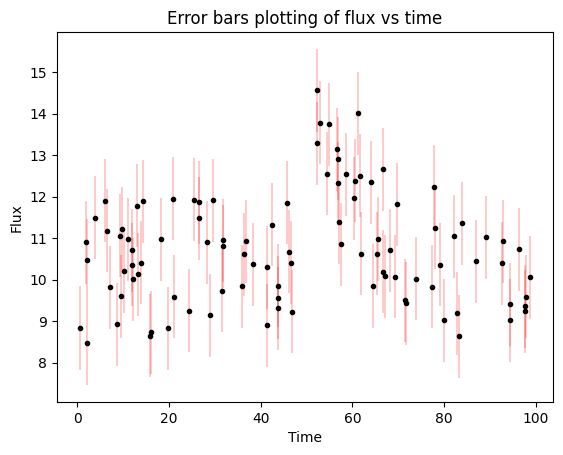

In [4]:
plt.errorbar(t, flux, yerr = yerr, fmt='.k', ecolor = 'red', elinewidth = 0.3)
plt.xlabel('Time')
plt.ylabel('Flux')
plt.title("Error bars plotting of flux vs time")
plt.savefig("./Images/EX_8_9_DataFluxTime.png")

In [5]:
#Costruiamo il modello
def model(theta, t):
    b, A, t_0, alfa = theta
    
    #b è l'ampiezza del background
    #A è l'ampiezza del burst
    #t_0 è il tempo in cui è avvenuto il burst
    #alfa è legato al tempo di decadimento del burst
    return np.where(t < t_0, b, b + A * np.exp(-alfa * (t - t_0)))

In [6]:
#Computiamo la likelihood
def log_likelihood(theta, t, flux, yerr, model):
    b, A, t_0, ln_alfa = theta # vettore dei parametri

    flux_i = model(theta, t) #valore teorico
 
    return -0.5*np.sum((flux - flux_i)**2 / (yerr**2)) # è la log likelihood assumendo che l'errore sul punto di flusso sia gaussiano centrato in flux e 
                                                       # con deviazione standard yerr

In [7]:
#Definiamo la pdf prior
def log_prior(theta):
    #Diciamo che il ln di alfa è uniforme in -5 e 5, ma nel modello compare alfa, dunque considerando ilo jacobiano ho che p(alfa) ~ 1/alfa, dunque 
    #facendo il log della prior ho che ln(1/alfa) = -ln(alfa)
    #per il resto è semplicemente una distribuzione uniforme, in particolare

    #b in Unif[0,50]
    #A in Unif[0,50]
    #t_0 in Unif[0,100]
    #ln(alfa) in Unif[-5,5] dunque alfa in [e^-5, e^5]

    b, A, t_0, alfa = theta 

    if (0 < A < 50 and 0 < b < 50 and 0 < t_0 < 100 and np.exp(-5) < alfa < np.exp(5)):
        return -np.log(alfa)
    else: return -np.inf #Dalla documentazione di emcee @@@ "In order to confine the walkers to a finite volume of the parameter space, 
                         #@@@ have your function return negative infinity outside of the volume corresponding to the logarithm of 0 prior probability 

#Definiamo la pdf posterior
def log_posterior(theta, t, flux, yerr, model):
    if np.isfinite(log_prior(theta)) == False: return -np.inf
    return log_prior(theta) + log_likelihood(theta, t, flux, yerr, model)

In [8]:
#Ora usiamo emcee per esplorare la posterior (ovvero la pdf dei parametri dati i data, è una pdf 4-Dimensionale)
N_dim = 4 #dimensioni dello spazio dei parametri
N_walkers = 32 #@@@ Walkers are the members of the ensemble. They are almost like separate Metropolis-Hastings chains but, 
               #@@@ of course, the proposal distribution for a given walker depends on the positions of all the other walkers in the ensemble
               #@@@ https://emcee.readthedocs.io/en/v2.2.1/user/faq/
N_steps = int(5e4) #nota che ogni walker farà questo numero di step

#Per inizializzare i walkers chiaramente servono dei punti di partenza. Possiamo scegliere dei parametri ad occhio e spostarci attorno a quei parametri
#con 32 valori leggermente discostati.
#@@@ The best technique seems to be to start in a small ball around the a priori preferred position. 
#@@@ Don’t worry, the walkers quickly branch out and explore the rest of the space.

theta_approx = [11, 4, 50, 0.1]
small_ball = theta_approx + 1e-3*np.random.rand(N_walkers, N_dim)

sampler = emcee.EnsembleSampler(N_walkers, N_dim, log_posterior, args = (t, flux, yerr, model))


In [14]:
start = time.time()
sampler.run_mcmc(small_ball, N_steps)
end = time.time()
elapsed = np.abs(end-start)
print(elapsed)

99.07155704498291


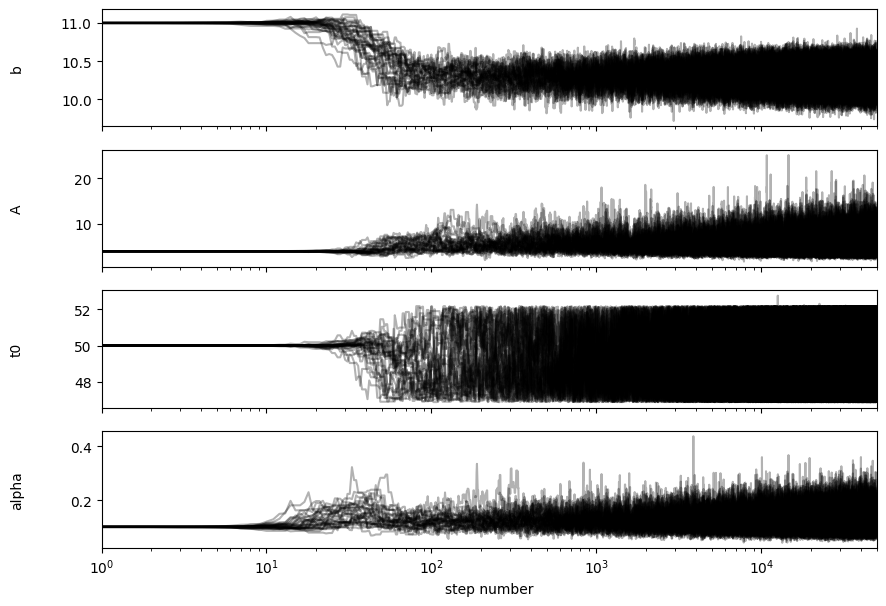

In [15]:
fig, axes = plt.subplots(4, figsize=(10, 7), sharex=True)
samples = sampler.get_chain()
labels = ["b","A","t0","alpha"]
for i in range(N_dim):
    ax = axes[i]
    ax.plot(samples[:, :, i], "k", alpha=0.3)
    ax.set_xlim(1, len(samples))
    ax.set_ylabel(labels[i])
    ax.yaxis.set_label_coords(-0.1, 0.5)
    ax.set_xscale('log')
axes[-1].set_xlabel("step number");
fig.savefig("./Images/EX_8_9_TracePlots.png")
#Da queste tracce possiamo estrare ad occhio un numero sensoato di burn-in. Inoltre emergono alcuni walker che sono rimasti congelati, soprattutto A e t0. 
#credo non dovrebbero influire troppo, ma in caso vediamo se toglierli.

In [16]:
burn_in = int(3e3)
#calcoliamo il tempo di autocorrelazione
tau = sampler.get_autocorr_time()
print(tau)
#thinniamo e burniamo
samples = sampler.get_chain(discard = burn_in, thin = int(np.max(tau)), flat = False) #flat = True appiattisce sul numero di walkers, un'unica grande lista
#Togliamo il walker rimasto freezato cercandolo vedendo gli acceptance rate
acc_frac = sampler.acceptance_fraction
walkers_idx = np.where(acc_frac > 0.05)[0] #accettiamo solo quelli con una frazione di ALMENO 0.05

samples = samples[:, walkers_idx, :] 

samples = samples.reshape(-1, N_dim) #reshape fa la stessa cosa del True
n_sim = len(samples)
print(f"Rimaniamo con {n_sim} samples")

[60.70168874 72.90420729 75.64169372 63.78454905]
Rimaniamo con 20032 samples


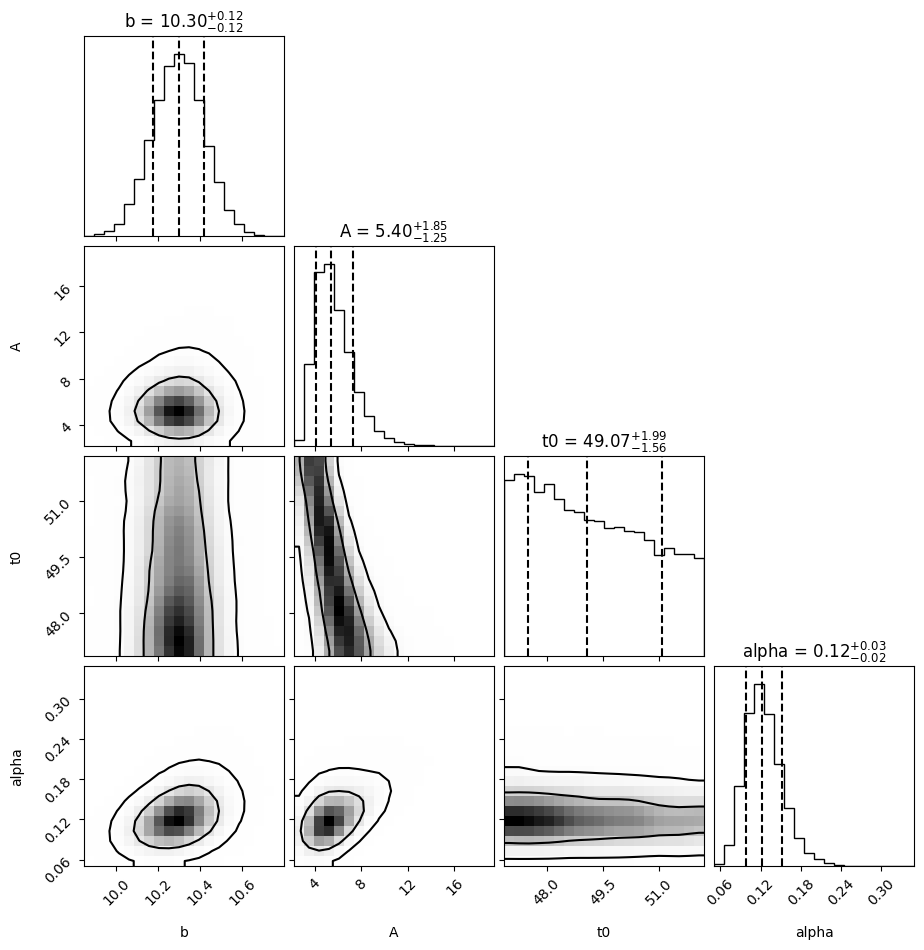

In [17]:
#Facciamo il corner plot, ovvero sulla diagonale le distribuzioni 1D Marginalizzate dei dati, sotto la diagonale un grafico con i livelli di credibilità
fig = corner.corner(
    samples, 
    labels=labels,
    # Quantiles
    quantiles=[0.16, 0.5, 0.84], 
    # Intervalli di credibilità 68% e 95%
    levels=(0.68, 0.95),
    show_titles=True, 
    smooth=1.0,          
    plot_datapoints=False
)
plt.savefig("./Images/EX_8_9_Corner.png")

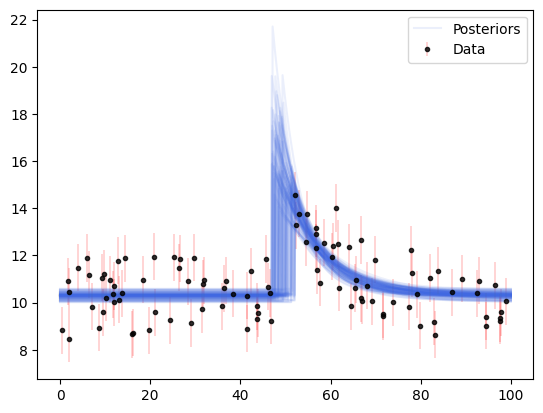

In [18]:
#Adesso prendiamo 100 punti random di samples e plottiamo le curve corrispondenti a quei parametri
t_ax=np.linspace(0,100, 1000)
plt.errorbar(t, flux, yerr = yerr, fmt='.k', ecolor = 'red', elinewidth = 0.3, alpha = 0.8, label ="Data")
which_points = np.random.randint(n_sim, size = 100)

for i, ind, in enumerate(which_points):
    #estriamo i parametri per il campione
    params = samples[ind]
    b_i, A_i, t_0_i, alfa_i = params 

    y_model = model(params, t_ax)

    plt.plot(t_ax, y_model, color = 'royalblue', alpha = 0.1, label = "Posteriors" if i == 0 else "")

plt.legend()
plt.savefig("./Images/EX_8_9_RandomCurves.png")

In [19]:
#Vediamo gli stimatori dei parametri (mediana, intervallo [5,95])
statistics = []
for i,j in enumerate(labels):
    l, median, u = np.percentile(samples[:,i],[5,50,95])
    print(j + "~  Mediana: " + str(median) + " + " + str(u-median) + " - " + str(median-l) + "\n")  
    statistics.append(median)
    

b~  Mediana: 10.296513352036108 + 0.19802627713842824 - 0.20468729936338725

A~  Mediana: 5.403425999875802 + 3.370151246999729 - 1.8133311035892108

t0~  Mediana: 49.070752817156226 + 2.7457004593924097 - 2.0038499295540078

alpha~  Mediana: 0.12211350539013652 + 0.053408483905610676 - 0.0372003859320124



[np.float64(10.296513352036108), np.float64(5.403425999875802), np.float64(49.070752817156226), np.float64(0.12211350539013652)]


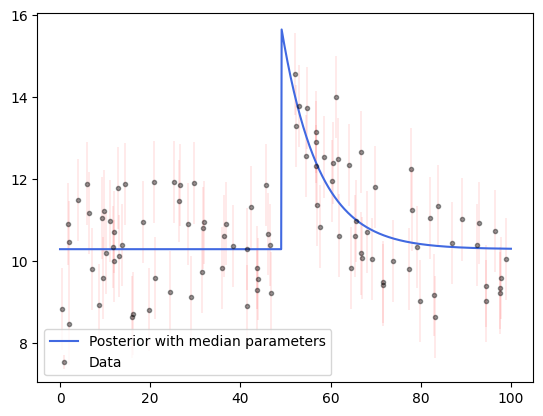

In [20]:
#Plottiamo con i parametri 
print(statistics)
b_m, A_m, t_0_m, alfa_m = statistics
plt.errorbar(t, flux, yerr = yerr, fmt='.k', ecolor = 'red', elinewidth = 0.3, alpha = 0.4, label ="Data")
plt.plot(t_ax, model(statistics, t_ax), color = 'royalblue', alpha = 1, label = "Posterior with median parameters")
plt.legend()
plt.savefig("./Images/EX_8_9_MedianCurve.png")

Let's go back to our previous example on the astrophysical transient.


8) Fit the same model from before with the same priors,  but this time use nested sampling.

$y = b$, for $t<t_0$

$y = b + A\exp[-\alpha(t-t_0)]$, for $t\geq t_0$

Be careful with how you transform your parameter space into a unit hypercube for the nested sampling priors (I used `ppf` from `scipy.stats.uniform`, but there are other ways to do it)

An appropriate check on whether you have done things correctly is that the posterior samples you get from the burst analysis here should give an equivalent corner plot to the MCMC you did earlier.

In [9]:
import dynesty
from dynesty import utils as dyfunc
from dynesty import plotting as dyplot
import scipy
transient = np.load("transient.npy")
t = transient[:,0]
flux = transient[:,1]
yerr = transient[:,2]
def ptform(u,model):
    """Transforms the uniform random variables `u ~ Unif[0., 1.)`
    to the parameters of interest."""

    x = np.array(u)  # copy u
    t0min,t0max = 0,100
    Amin,Amax=0,50
    bmin,bmax=0,50
    alphamin,alphamax=np.exp(-5),np.exp(5)
        
    x[1] = scipy.stats.uniform(loc=Amin,scale=Amax-Amin).ppf(u[0])
    x[0] = scipy.stats.uniform(loc=bmin,scale=bmax-bmin).ppf(u[1])
    x[2] = scipy.stats.uniform(loc=t0min,scale=t0max-t0min).ppf(u[2])
   
    if model =='model':
        x[3] = scipy.stats.loguniform.ppf(u[3],alphamin,alphamax)
    return x

In [10]:
# Define and run sampler
sampler = dynesty.NestedSampler(log_likelihood, ptform, N_dim , logl_args=[t, flux, yerr, model],ptform_args=['model'],nlive=300)
sampler.run_nested()
sresults = sampler.results

C:\Users\Martina\AppData\Local\Temp\ipykernel_12560\3181919911.py:9: RuntimeWarning: overflow encountered in exp
  return np.where(t < t_0, b, b + A * np.exp(-alfa * (t - t_0)))
C:\Users\Martina\AppData\Local\Temp\ipykernel_12560\3181919911.py:9: RuntimeWarning: overflow encountered in multiply
  return np.where(t < t_0, b, b + A * np.exp(-alfa * (t - t_0)))
1098it [00:25, 10.90it/s, bound: 1 | nc: 69 | ncall: 11045 | eff(%):  9.941 | loglstar:   -inf < -178.920 <    inf | logz: -188.132 +/-  0.163 | dlogz: 110.112 >  0.309]   C:\Users\Martina\AppData\Local\Temp\ipykernel_12560\3181919911.py:9: RuntimeWarning: overflow encountered in exp
  return np.where(t < t_0, b, b + A * np.exp(-alfa * (t - t_0)))
C:\Users\Martina\AppData\Local\Temp\ipykernel_12560\3181919911.py:9: RuntimeWarning: overflow encountered in multiply
  return np.where(t < t_0, b, b + A * np.exp(-alfa * (t - t_0)))
1154it [00:26, 61.61it/s, bound: 1 | nc: 5 | ncall: 11325 | eff(%): 10.190 | loglstar:   -inf < -152.175 <

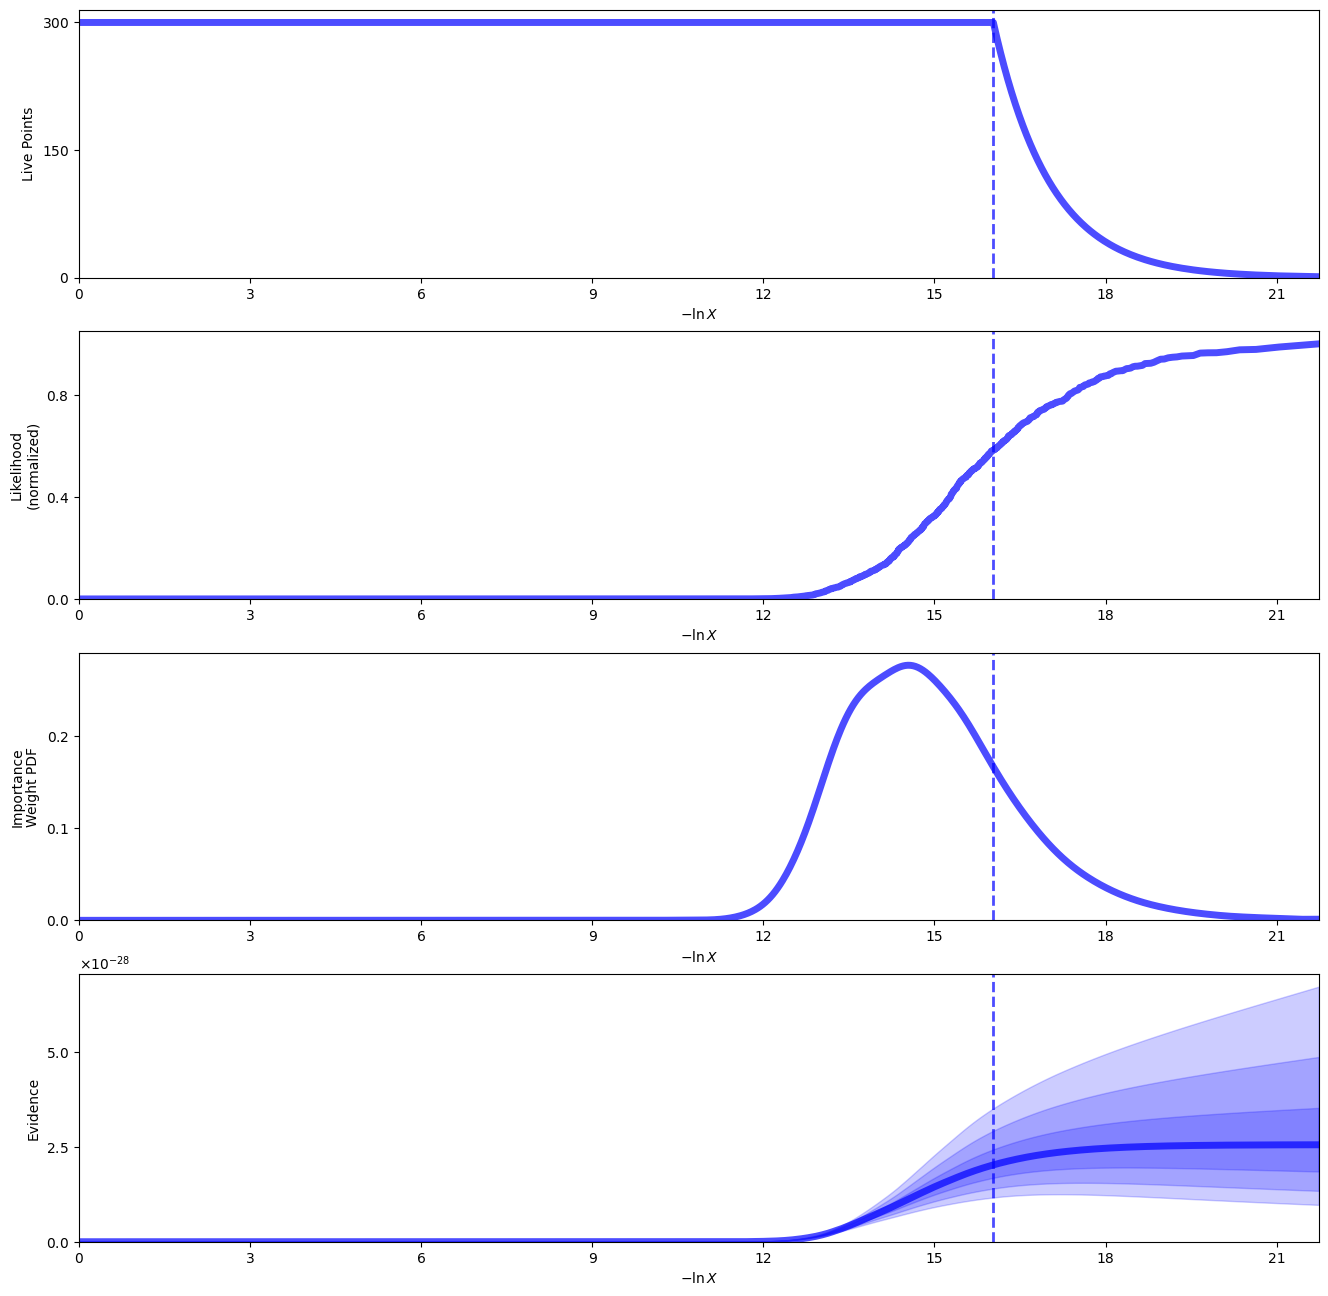

In [11]:
rfig, raxes = dyplot.runplot(sresults)

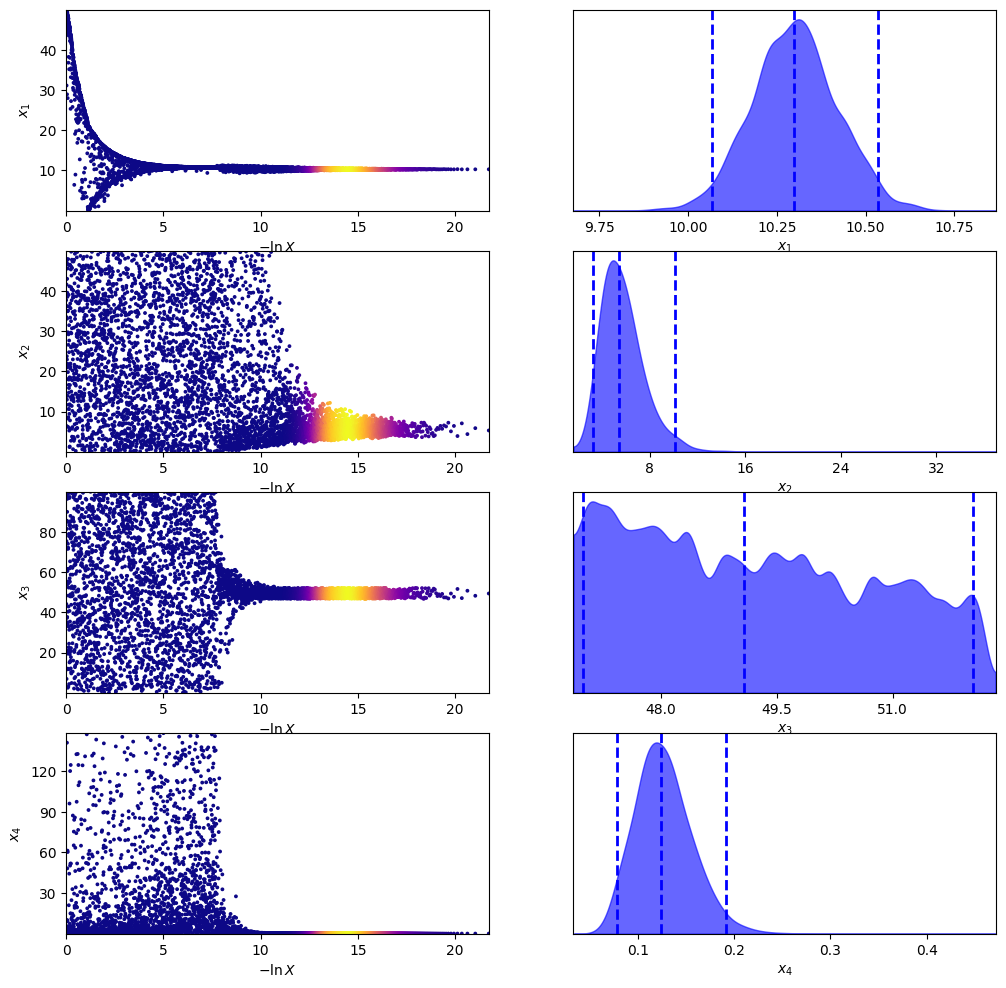

In [12]:
tfig, taxes = dyplot.traceplot(sresults)

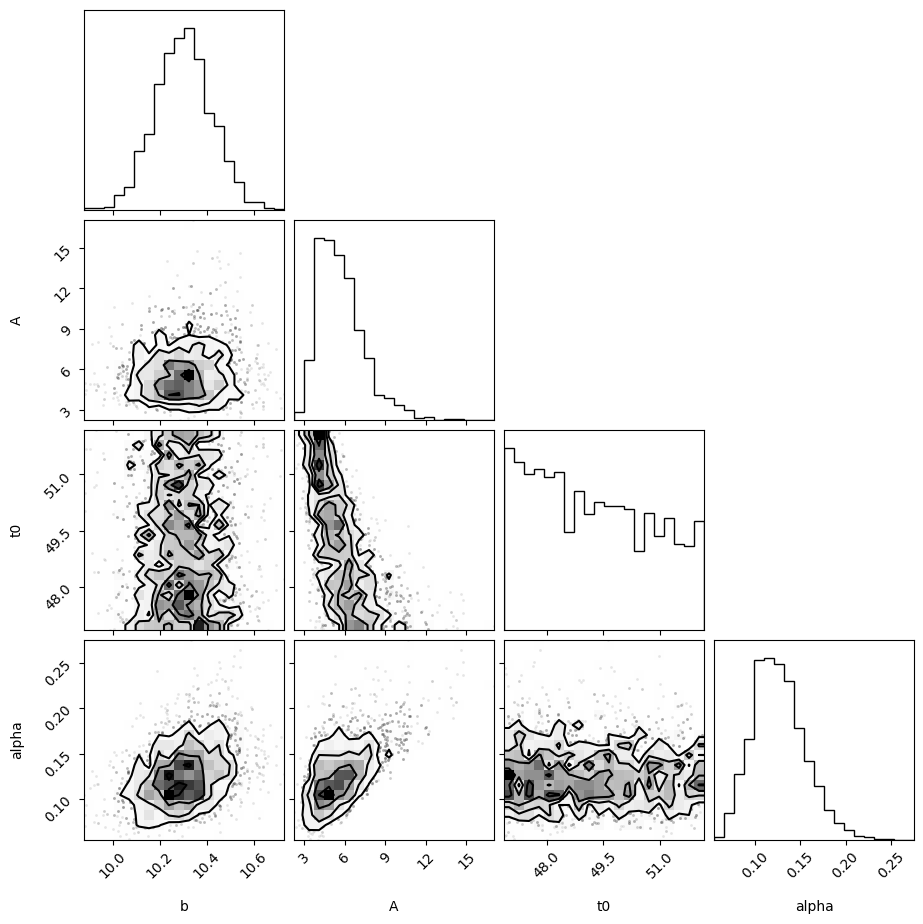

In [13]:
samples = sresults.samples  # samples
weights = np.exp(sresults.logwt - sresults.logz[-1])  # normalized weights

labels = ["b","A","t0","alpha"]

samples_equal = dyfunc.resample_equal(samples, weights)
corner.corner(samples_equal,labels=labels);



In [14]:
quantiles = [dyfunc.quantile(samps, [0.05, 0.5, 0.95], weights=weights)
             for samps in samples.T]
for q,l in zip(quantiles,labels):
    low,med,up=q
    print(l+"   "+str(med)+" +"+str(up-med)+" -"+str(med-low))

sresults.summary()

b   10.299743994094866 +0.2009728197235905 -0.19095550451771182
A   5.490064468044119 +3.556133661388623 -1.9667399380179136
t0   49.07799466113155 +2.7874316405982924 -2.012281928657785
alpha   0.12400586370696219 +0.05464716334498841 -0.04135601102200058
Summary
nlive: 300
niter: 4817
ncall: 98173
eff(%):  5.212
logz: -63.534 +/-  0.322


7) Another possible model that may explain the data is a Gaussian profile described by:

$y = b + A\exp[-(t-t_0)^2 / 2\sigma_W^2]$

Fit this model usign nested sampling and reasonable priors (this time is up to you to decide...)

9) Unlike MCMCs, nested sampling provides the Bayesian evidence. Compute the Bayesian evidence for this Gaussian model, and for the original burst model. Which model is the favored description of the data? Express this in terms of the Jeffrey's scale.

In [15]:
def gprofile(theta,t):
    b,A,t0,sigmaW=theta     
    return b+A*np.exp(-(((t-t0)/sigmaW)**2 ) / 2)

def log_likelihood(theta, t, flux, yerr, model):
    b, A, t_0, ln_alfa = theta # vettore dei parametri
    y_fit = gprofile(theta, t)
        
    return -0.5 * np.sum((flux-y_fit)**2 / yerr**2 ) 

def ptform(u,model):

    #parameters
    x = np.array(u)  # copy u
    t0min,t0max = 0,100
    Amin,Amax=0,50
    bmin,bmax=0,50
    sigmaWmin, sigmaWmax = 2, 10

    x[1] = scipy.stats.uniform(loc=Amin,scale=Amax-Amin).ppf(u[0])
    x[0] = scipy.stats.uniform(loc=bmin,scale=bmax-bmin).ppf(u[1])
    x[2] = scipy.stats.uniform(loc=t0min,scale=t0max-t0min).ppf(u[2])
    x[3] = scipy.stats.loguniform.ppf(u[3],sigmaWmin,sigmaWmax)
        #x[3] = scipy.stats.uniform(loc=sigmaWmin,scale=sigmaWmax-sigmaWmin).ppf(u[3])

    return x

In [16]:
sampler = dynesty.NestedSampler(log_likelihood, ptform, N_dim , logl_args=[t, flux, yerr, gprofile],ptform_args=['gprofile'],nlive=300)
sampler.run_nested()
sresults2 = sampler.results

4716it [01:14, 63.73it/s, +300 | bound: 51 | nc: 1 | ncall: 27211 | eff(%): 18.639 | loglstar:   -inf < -52.465 <    inf | logz: -66.935 +/-  0.213 | dlogz:  0.001 >  0.309]


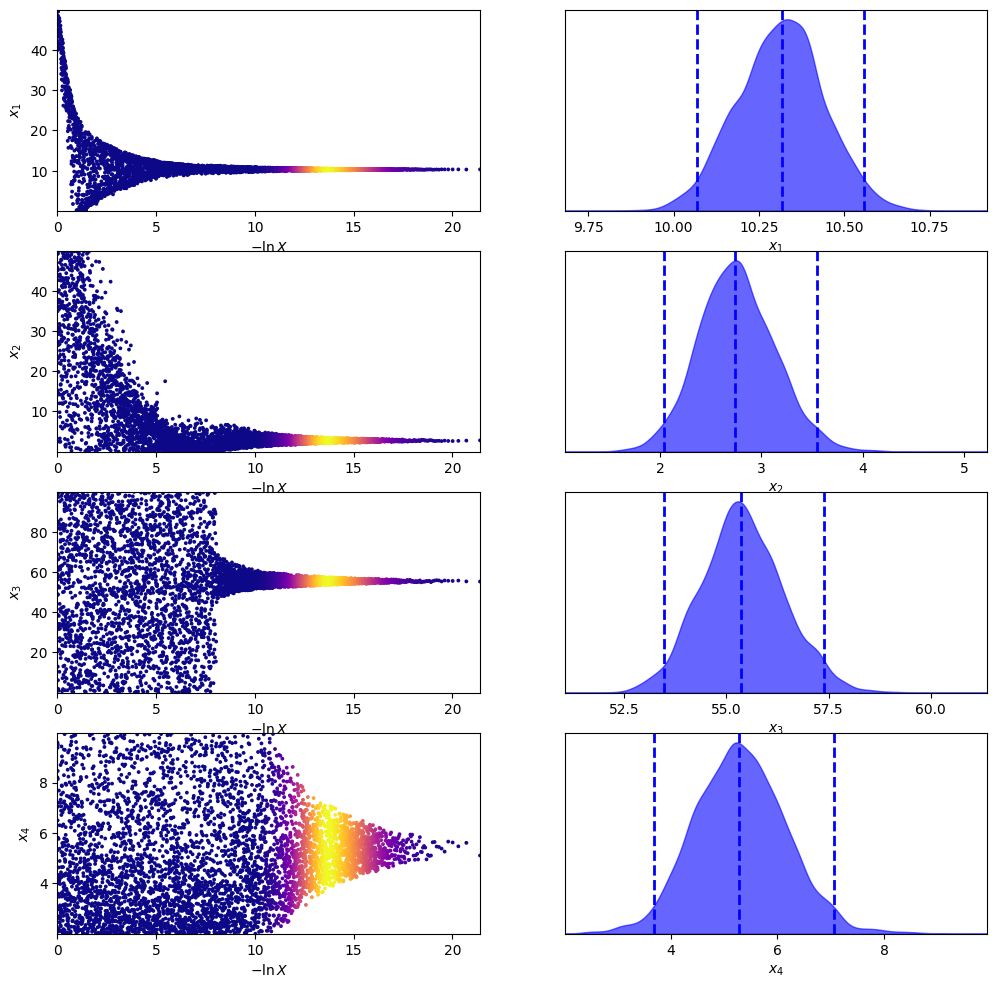

In [17]:
tfig, taxes = dyplot.traceplot(sresults2)

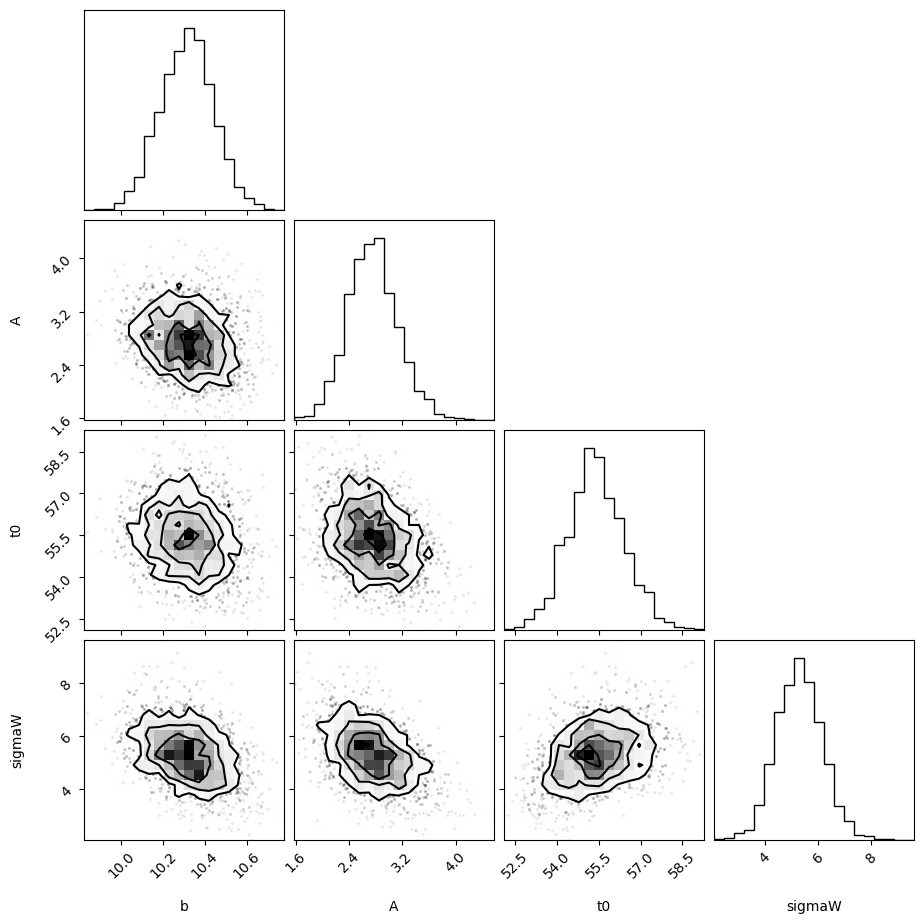

In [18]:
samples = sresults2.samples  # samples
weights = np.exp(sresults2.logwt - sresults2.logz[-1])  # normalized weights

labels = ["b","A","t0","sigmaW"]

samples_equal = dyfunc.resample_equal(samples, weights)
corner.corner(samples_equal,labels=labels);

In [19]:
sresults2.summary()

Summary
nlive: 300
niter: 4716
ncall: 26911
eff(%): 18.639
logz: -66.935 +/-  0.315


In [20]:
#Calcoliamo i bayesian odd ratios. Logz è il logaritmo dell'evidenza Z = p(D | M)
#L'errore sulla evidenza si ottiene da sresults.logzerr propagando l'errore sul bayesian factor 
delta_logz = sresults.logz[-1] - sresults2.logz[-1] #bayesian factor logaritmico
delta_logz_error = np.sqrt(sresults.logzerr[-1]**2 + sresults2.logzerr[-1]**2)
print(delta_logz)
print(delta_logz_error)
bf = np.exp(delta_logz)
bf_err = bf * delta_logz_error
print(f"Con un bayesian factor: {bf} +- {bf_err}, possiamo dire che il modello burst è migliore")

3.400694526488607
0.45078547886747783
Con un bayesian factor: 29.984918137107744 +- 13.516765681238235, possiamo dire che il modello burst è migliore
